In [1]:
!nvidia-smi

Fri Oct  2 09:38:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import time
import numpy as np
import numba
import matplotlib.pyplot as plt
from numba import cuda

In [3]:
from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]

Saving cat.png to cat.png


In [4]:
src = plt.imread(fname)

if src.dtype != np.uint8:
    src = (src * 255).astype(np.uint8)
if src.shape[2] == 4:
    src = np.ascontiguousarray(src[:, :, :3])

imageHeight, imageWidth = src.shape[0], src.shape[1]
pixelCount = imageHeight * imageWidth
print(src.shape, pixelCount, 'pixels')

(491, 553, 3) 271523 pixels


In [5]:
gaussian = np.array([
    [0,  0,   1,   2,   1,  0,  0],
    [0,  3,  13,  22,  13,  3,  0],
    [1, 13,  59,  97,  59, 13,  1],
    [2, 22,  97, 159,  97, 22,  2],
    [1, 13,  59,  97,  59, 13,  1],
    [0,  3,  13,  22,  13,  3,  0],
    [0,  0,   1,   2,   1,  0,  0],
], np.float32)

print(gaussian.sum())

1003.0


## CPU

In [6]:
def blurCPU(src, dst, flt):
    for y in range(src.shape[0]):
        for x in range(src.shape[1]):
            for c in range(3):
                total = 0.0
                weight = 0.0
                for j in range(-3, 4):
                    for i in range(-3, 4):
                        yy = y + j
                        xx = x + i
                        if 0 <= yy < src.shape[0] and 0 <= xx < src.shape[1]:
                            w = flt[j + 3, i + 3]
                            total += src[yy, xx, c] * w
                            weight += w
                dst[y, x, c] = np.uint8(total / weight)


hostDst = np.zeros_like(src)

start = time.time()
blurCPU(src, hostDst, gaussian)
cpuTime = time.time() - start
print('CPU: %.2f s' % cpuTime)

CPU: 42.04 s


## GPU, without shared memory

In [7]:
@cuda.jit
def blur(src, dst, flt):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx >= src.shape[1] or tidy >= src.shape[0]:
        return

    for c in range(3):
        total = numba.float32(0)
        weight = numba.float32(0)
        for j in range(-3, 4):
            for i in range(-3, 4):
                yy = tidy + j
                xx = tidx + i
                if 0 <= yy < src.shape[0] and 0 <= xx < src.shape[1]:
                    w = flt[j + 3, i + 3]
                    total += src[yy, xx, c] * w
                    weight += w
        dst[tidy, tidx, c] = np.uint8(total / weight)

## GPU with share memory


In [8]:
@cuda.jit
def blurShared(src, dst, flt):
    tile = cuda.shared.array((7, 7), numba.float32)

    tid = cuda.threadIdx.x + cuda.threadIdx.y * cuda.blockDim.x
    nthreads = cuda.blockDim.x * cuda.blockDim.y
    for k in range(tid, 49, nthreads):
        tile[k // 7, k % 7] = flt[k // 7, k % 7]
    cuda.syncthreads()

    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx >= src.shape[1] or tidy >= src.shape[0]:
        return

    for c in range(3):
        total = numba.float32(0)
        weight = numba.float32(0)
        for j in range(-3, 4):
            for i in range(-3, 4):
                yy = tidy + j
                xx = tidx + i
                if 0 <= yy < src.shape[0] and 0 <= xx < src.shape[1]:
                    w = tile[j + 3, i + 3]
                    total += src[yy, xx, c] * w
                    weight += w
        dst[tidy, tidx, c] = np.uint8(total / weight)

In [9]:
devSrc = cuda.to_device(src)
devDst = cuda.device_array(src.shape, np.uint8)
devFlt = cuda.to_device(gaussian)

blockSize = (32, 32)
gridSize = ((imageWidth + blockSize[0] - 1) // blockSize[0],
            (imageHeight + blockSize[1] - 1) // blockSize[1])


def measure(kernel, bs, runs=10):
    gs = ((imageWidth + bs[0] - 1) // bs[0],
          (imageHeight + bs[1] - 1) // bs[1])
    kernel[gs, bs](devSrc, devDst, devFlt)
    cuda.synchronize()
    start = time.time()
    for _ in range(runs):
        kernel[gs, bs](devSrc, devDst, devFlt)
    cuda.synchronize()
    return (time.time() - start) / runs


t1 = measure(blur, blockSize)
t2 = measure(blurShared, blockSize)
print('global: %.6f s, speedup %.0fx' % (t1, cpuTime / t1))
print('shared: %.6f s, speedup %.0fx' % (t2, cpuTime / t2))

global: 0.000525 s, speedup 80070x
shared: 0.000535 s, speedup 78564x


True
0


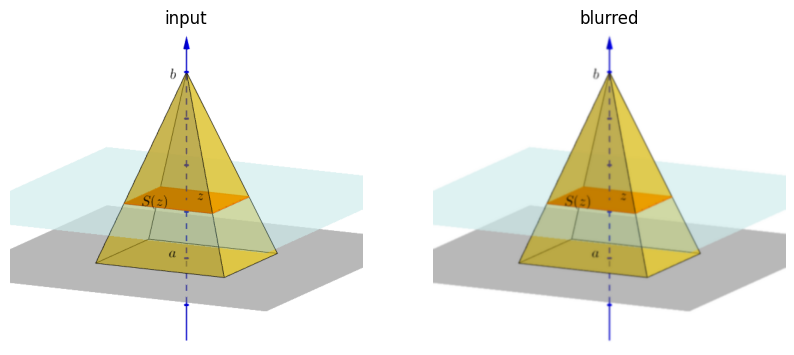

In [10]:
blur[gridSize, blockSize](devSrc, devDst, devFlt)
cuda.synchronize()
out1 = devDst.copy_to_host()

blurShared[gridSize, blockSize](devSrc, devDst, devFlt)
cuda.synchronize()
out2 = devDst.copy_to_host()

print(np.array_equal(out1, out2))
print(np.abs(out1.astype(int) - hostDst.astype(int)).max())

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(src); ax[0].set_title('input'); ax[0].axis('off')
ax[1].imshow(out2); ax[1].set_title('blurred'); ax[1].axis('off')
plt.show()

## Block size vs speedup


In [11]:
blockSizes = [(4, 4), (8, 8), (16, 16), (32, 32),
              (32, 4), (32, 8), (32, 16), (16, 8), (8, 16)]

sGlobal = []
sShared = []

for bs in blockSizes:
    a = measure(blur, bs)
    b = measure(blurShared, bs)
    sGlobal.append(cpuTime / a)
    sShared.append(cpuTime / b)
    print('%-9s global %.6f s (%5.0fx)   shared %.6f s (%5.0fx)'
          % (bs, a, cpuTime / a, b, cpuTime / b))

(4, 4)    global 0.001083 s (38823x)   shared 0.001154 s (36423x)
(8, 8)    global 0.000600 s (70111x)   shared 0.000606 s (69420x)
(16, 16)  global 0.000490 s (85864x)   shared 0.000535 s (78638x)
(32, 32)  global 0.000520 s (80856x)   shared 0.000525 s (80114x)
(32, 4)   global 0.000485 s (86628x)   shared 0.000530 s (79278x)
(32, 8)   global 0.000498 s (84357x)   shared 0.000537 s (78216x)
(32, 16)  global 0.000507 s (82932x)   shared 0.000533 s (78888x)
(16, 8)   global 0.000479 s (87793x)   shared 0.000517 s (81374x)
(8, 16)   global 0.000601 s (69966x)   shared 0.000609 s (69051x)


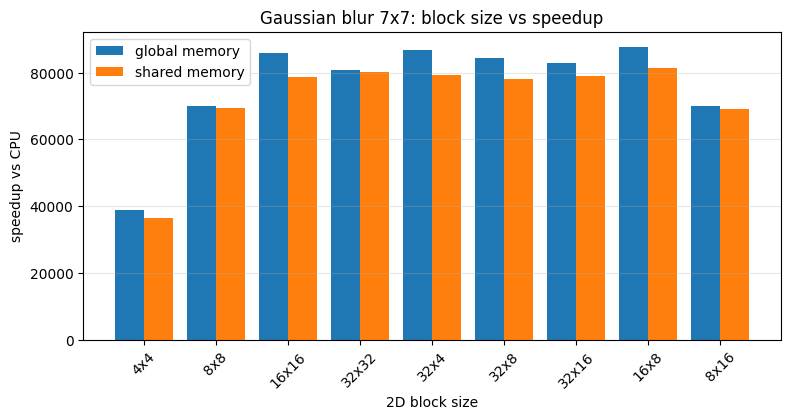

fastest global: (16, 8) 87793x
fastest shared : (16, 8) 81374x


In [12]:
labels = ['%dx%d' % bs for bs in blockSizes]
x = np.arange(len(labels))

plt.figure(figsize=(9, 4))
plt.bar(x - 0.2, sGlobal, 0.4, label='global memory')
plt.bar(x + 0.2, sShared, 0.4, label='shared memory')
plt.xticks(x, labels, rotation=45)
plt.ylabel('speedup vs CPU')
plt.xlabel('2D block size')
plt.title('Gaussian blur 7x7: block size vs speedup')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('blur_blocksize.png', dpi=150, bbox_inches='tight')
plt.show()

print('fastest global:', blockSizes[int(np.argmax(sGlobal))], '%.0fx' % max(sGlobal))
print('fastest shared :', blockSizes[int(np.argmax(sShared))], '%.0fx' % max(sShared))

In [13]:
plt.imsave('blurred.png', out2)
files.download('blur_blocksize.png')
files.download('blurred.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>